Metode                      RMSE train   RMSE test   R2 test   Waktu (s)
Normal equation                 0.7197      0.7456    0.5758      0.0158
sklearn LinearRegression        0.7197      0.7456    0.5758      0.0049
Batch GD (manual)               0.7197      0.7456    0.5758      0.2190
SGD (sklearn)                   0.7198      0.7448    0.5766      0.0483

Koefisien (data sudah distandardisasi):
              Normal equatio  sklearn Linear  Batch GD (manu   SGD (sklearn)
intercept             2.0719          2.0719          2.0719          2.0719
MedInc                0.8544          0.8544          0.8544          0.8599
HouseAge              0.1225          0.1225          0.1225          0.1271
AveRooms             -0.2944         -0.2944         -0.2944         -0.3043
AveBedrms             0.3393          0.3393          0.3393          0.3411
Population           -0.0023         -0.0023         -0.0023         -0.0004
AveOccup             -0.0408         -0.0408         -0

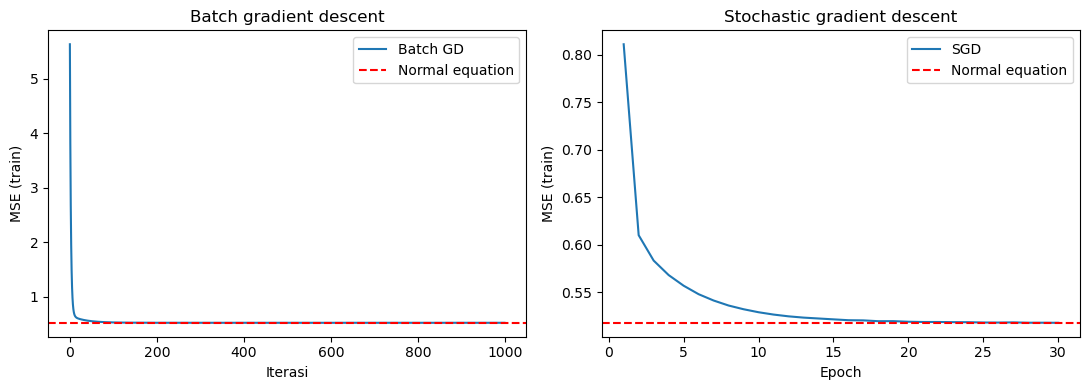

In [ ]:
import time
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, SGDRegressor
from sklearn.metrics import mean_squared_error, r2_score

# 1. Data
data = fetch_california_housing()
X, y = data.data, data.target
feature_names = list(data.feature_names)

# 2. Split + standardisasi
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
scaler = StandardScaler().fit(X_train)
X_train_s = scaler.transform(X_train)
X_test_s = scaler.transform(X_test)

def add_bias(X):
    return np.c_[np.ones(len(X)), X]   # kolom 1 untuk intercept (beta_0)

Xtr, Xte = add_bias(X_train_s), add_bias(X_test_s)

def evaluate(beta, name, seconds):
    pred_tr, pred_te = Xtr @ beta, Xte @ beta
    return {
        "name": name,
        "rmse_train": np.sqrt(mean_squared_error(y_train, pred_tr)),
        "rmse_test": np.sqrt(mean_squared_error(y_test, pred_te)),
        "r2_test": r2_score(y_test, pred_te),
        "time": seconds,
    }

results, betas = [], {}

# 3. Closed form
# 3a. Normal equation manual: beta = (X^T X)^-1 X^T y
t0 = time.perf_counter()
beta_ne = np.linalg.solve(Xtr.T @ Xtr, Xtr.T @ y_train)
results.append(evaluate(beta_ne, "Normal equation", time.perf_counter() - t0))
betas["Normal equation"] = beta_ne

# 3b. scikit-learn LinearRegressio
t0 = time.perf_counter()
lr = LinearRegression().fit(X_train_s, y_train)
beta_lr = np.r_[lr.intercept_, lr.coef_]
results.append(evaluate(beta_lr, "sklearn LinearRegression", time.perf_counter() - t0))
betas["sklearn LinearRegression"] = beta_lr

# 4. Batch gradient descent
#    Loss = MSE = (1/n) * sum((X beta - y)^2)  ->  gradien = (2/n) * X^T (X beta - y)
def batch_gd(X, y, lr=0.1, n_iter=1000):
    beta = np.zeros(X.shape[1])
    history = []
    for _ in range(n_iter):
        residual = X @ beta - y
        history.append(np.mean(residual ** 2))
        beta -= lr * (2 / len(y)) * (X.T @ residual)
    return beta, history

t0 = time.perf_counter()
beta_gd, hist_gd = batch_gd(Xtr, y_train)
results.append(evaluate(beta_gd, "Batch GD (manual)", time.perf_counter() - t0))
betas["Batch GD (manual)"] = beta_gd

# 5. Stochastic gradient descent (scikit-learn)
#    partial_fit = 1 epoch (satu kali lewat seluruh data, update per sampel)
n_epochs = 30
# sgd = SGDRegressor(penalty=None, learning_rate="constant", eta0=0.01, random_state=42)
sgd = SGDRegressor(penalty=None, learning_rate="constant", eta0=0.0001, random_state=42)
rng = np.random.default_rng(42)
hist_sgd = []

t0 = time.perf_counter()
for _ in range(n_epochs):
    idx = rng.permutation(len(y_train))            # acak urutan data tiap epoch
    sgd.partial_fit(X_train_s[idx], y_train[idx])
    hist_sgd.append(mean_squared_error(y_train, sgd.predict(X_train_s)))
sgd_time = time.perf_counter() - t0

beta_sgd = np.r_[sgd.intercept_, sgd.coef_]
results.append(evaluate(beta_sgd, "SGD (sklearn)", sgd_time))
betas["SGD (sklearn)"] = beta_sgd

# 6. Perbandingan
print(f"{'Metode':26s}{'RMSE train':>12s}{'RMSE test':>12s}{'R2 test':>10s}{'Waktu (s)':>12s}")
for r in results:
    print(f"{r['name']:26s}{r['rmse_train']:12.4f}{r['rmse_test']:12.4f}"
          f"{r['r2_test']:10.4f}{r['time']:12.4f}")

print("\nKoefisien (data sudah distandardisasi):")
names = ["intercept"] + feature_names
print(f"{'':12s}" + "".join(f"{k[:14]:>16s}" for k in betas))
for i, nm in enumerate(names):
    print(f"{nm:12s}" + "".join(f"{b[i]:16.4f}" for b in betas.values()))

print("\nSelisih maksimum koefisien dibanding Normal equation:")
for k, b in betas.items():
    print(f"  {k:26s}{np.max(np.abs(b - beta_ne)):.6f}")

# 7. Kurva loss
mse_ne = np.mean((Xtr @ beta_ne - y_train) ** 2)

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(hist_gd, label="Batch GD")
ax[0].axhline(mse_ne, color="red", linestyle="--", label="Normal equation")
ax[0].set_xlabel("Iterasi")
ax[0].set_ylabel("MSE (train)")
ax[0].set_title("Batch gradient descent")
ax[0].legend()

ax[1].plot(range(1, n_epochs + 1), hist_sgd, label="SGD")
ax[1].axhline(mse_ne, color="red", linestyle="--", label="Normal equation")
ax[1].set_xlabel("Epoch")
ax[1].set_ylabel("MSE (train)")
ax[1].set_title("Stochastic gradient descent")
ax[1].legend()

plt.tight_layout()
plt.show()